<a href="https://colab.research.google.com/github/mamontoff2018-lgtm/google-colab/blob/main/MO8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
dataset = pd.read_csv('Salary_Data.csv')
dataset.head()



,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [9]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 1].values
print("Матрица признаков"); print(X[:5])
print("Зависимая переменная"); print(y[:5])

Матрица признаков
[[1.1]
 [1.3]
 [1.5]
 [2. ]
 [2.2]]
Зависимая переменная
[39343. 46205. 37731. 43525. 39891.]


In [10]:
# from sklearn.cross_validation import train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/4, random_state = 0)

In [12]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)



LinearRegression()

In [13]:
y_pred = regressor.predict(X_test)
print(y_pred)



[ 41056.25705466 123597.70938378  65443.50433372  63567.56223533
 116093.94099022 108590.17259667 117031.91203942  64505.53328452]


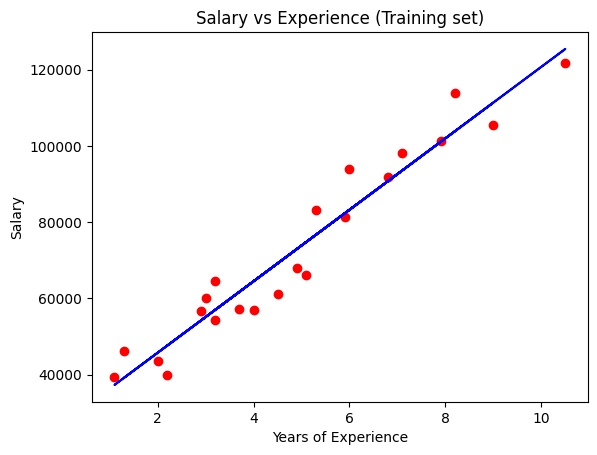

In [14]:
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

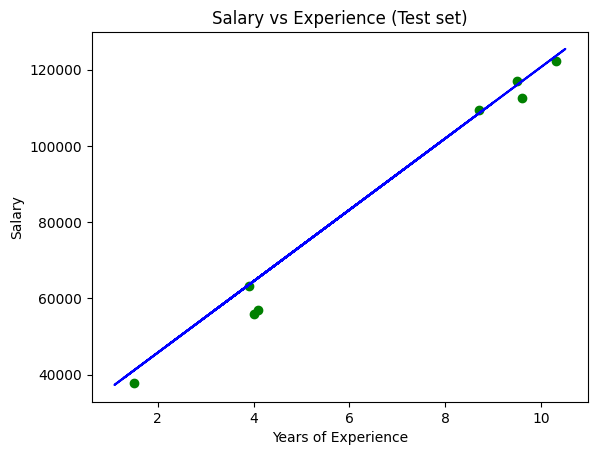

In [15]:
plt.scatter(X_test, y_test, color = 'green')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

In [28]:
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
dataset = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
dataset['target'] = diabetes.target

dataset.head()

X = diabetes.data
y = diabetes.target

print("Матрица признаков"); print(X[:5])
print("Зависимая переменная"); print(y[:5])

Матрица признаков
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
Зависимая переменная
[151.  75. 141. 206. 135.]


In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [31]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)



LinearRegression()

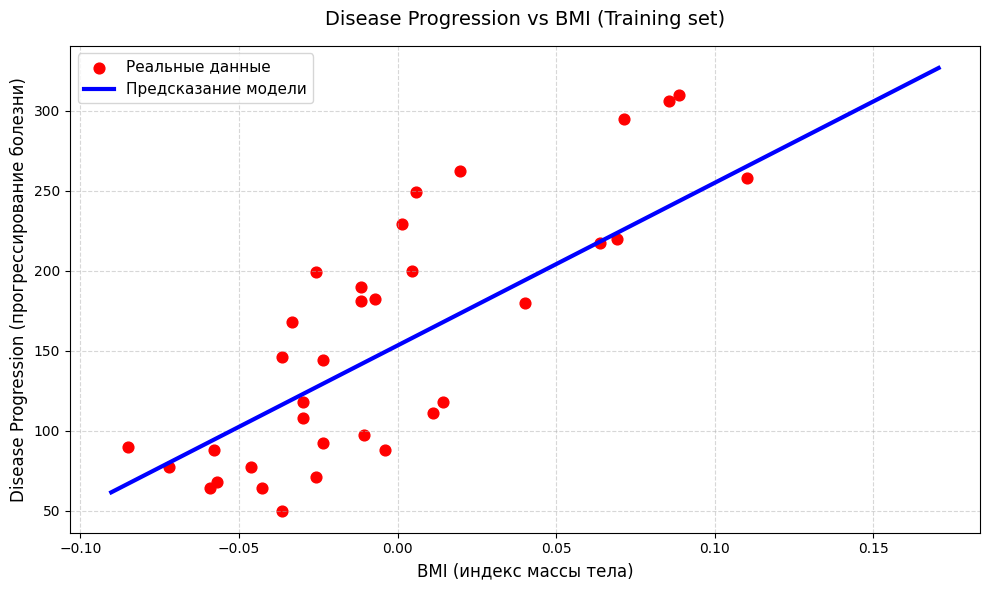

In [43]:
X_bmi = X_train[:, 2].reshape(-1, 1)
y_train_bmi = y_train

regressor_bmi = LinearRegression()
regressor_bmi.fit(X_bmi, y_train_bmi)

sort_idx = np.argsort(X_bmi[:, 0])

plt.figure(figsize=(10, 6))
plt.scatter(X_bmi[::10, 0], y_train_bmi[::10], color='red', s=60, label='Реальные данные')
plt.plot(X_bmi[sort_idx, 0], regressor_bmi.predict(X_bmi)[sort_idx],
         color='blue', linewidth=3, label='Предсказание модели')

plt.title('Disease Progression vs BMI (Training set)', fontsize=14, pad=15)
plt.xlabel('BMI (индекс массы тела)', fontsize=12)
plt.ylabel('Disease Progression (прогрессирование болезни)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

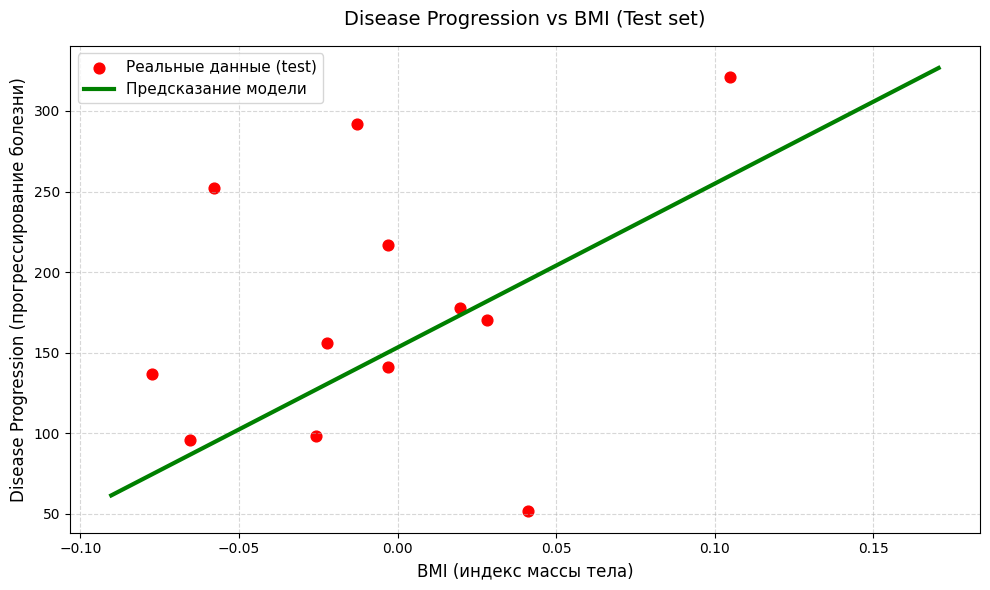

In [45]:
X_test_bmi = X_test[:, 2].reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_test_bmi[::10, 0], y_test[::10], color='red', s=60, label='Реальные данные (test)')
plt.plot(X_bmi[sort_idx, 0], regressor_bmi.predict(X_bmi)[sort_idx],
         color='green', linewidth=3, label='Предсказание модели')

plt.title('Disease Progression vs BMI (Test set)', fontsize=14, pad=15)
plt.xlabel('BMI (индекс массы тела)', fontsize=12)
plt.ylabel('Disease Progression (прогрессирование болезни)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()